# Module 11: Simulations and Unit Tests

---

In the previous assignment you learned to compute spectral power. In the next one, you will test whether power differ between recalled and non-recalled words. Before you trust that answer on real data, you should ask:

**If your power calculation had a bug, how would you know?**
You could still get a reasonable plot and p-value with buggy code, as real data does not come with an answer key.

The solution is to run your analysis on data where you already know the answer - this is a **simulation**. And once you can generate such data, you can run a quick automatic test - a **unit test**.

**What we will do:** build fake/simulated EEG containing a 6 Hz oscillation of known strength, measure its power with the tools from Module 10, confirm we get back what we expect, then simulate an experiment with a known memory effect - specifically one with NO effect, to see whether our statistics claim there is one anyway.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy.stats import ttest_ind

### Note: Random numbers for reproducibility

Modern numpy gives you a **generator object** you create and pass explicitly:

```python
rng = np.random.default_rng(42)
x = rng.normal(size=10)
```

Everything below takes an `rng`/ `seed` - every test should be able to reproduce its output.

## Background: pink noise

Real EEG is mostly NOT plain oscillations. It is broadband activity whose power falls off as $1/f$, i.e.
much more power at lower frequencies than high. We need that realism, or our simulated data will be far too easy to analyze.

To build it in the frequency domain: give each frequency an amplitude of $f^{-\alpha/2}$ and a random
phase, then inverse-FFT.

In [ ]:
def pink_noise(n_samples, amplitude, rng, exponent=1.0):
    '''Pink noise with standard deviation ~ amplitude'''
    n = n_samples + (n_samples % 2)
    scales = np.linspace(0, 0.5, n // 2 + 1)[1:] ** (-exponent / 2)
    spectrum = rng.normal(scale=scales) * np.exp(2j * np.pi * rng.random(n // 2))
    sigma = np.sqrt(2 * np.sum(scales ** 2)) / n            # normalize to unit std
    return amplitude * np.fft.irfft(np.concatenate([[0], spectrum]))[:n_samples] / sigma

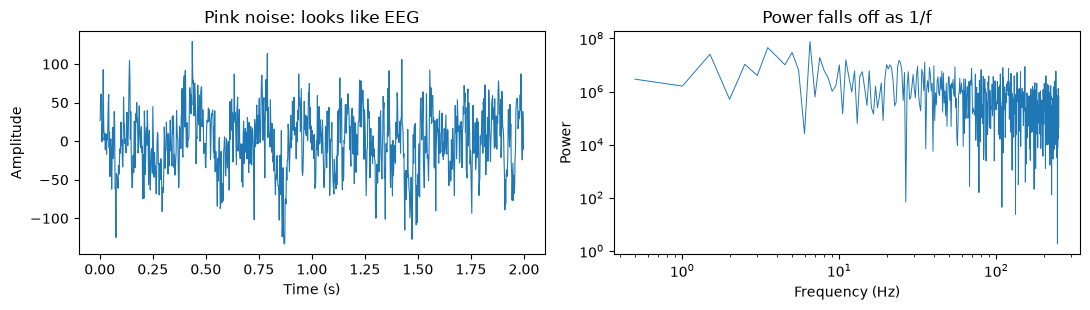

requested std 50 | this draw: 40.9 | mean of 200 draws: 50.1


In [4]:
rng = np.random.default_rng(0)
noise = pink_noise(1000, amplitude=50, rng=rng)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(np.arange(1000) / 500, noise, lw=0.8)
ax[0].set(xlabel="Time (s)", ylabel="Amplitude", title="Pink noise: looks like EEG")

freqs = np.fft.rfftfreq(1000, 1 / 500)[1:]
ax[1].loglog(freqs, np.abs(np.fft.rfft(noise)[1:]) ** 2, lw=0.7)
ax[1].set(xlabel="Frequency (Hz)", ylabel="Power", title="Power falls off as 1/f")
plt.tight_layout(); plt.show()

draws = [pink_noise(1000, 50, rng).std() for _ in range(200)]
print(f"requested std 50 | this draw: {noise.std():.1f} | mean of 200 draws: {np.mean(draws):.1f}")

Note the two numbers at the bottom. The normalization is right on average, but any single
realization is majorly off, because 1/f noise is dominated by a few random low-frequency
components. Remember this when we write tests: we cannot infer results from a single draw.

## Adding a known oscillation

Now, we simulate the answer. Each trial gets a sine wave at a chosen frequency and a
chosen amplitude, starting at a random phase, buried in pink noise.

The random start phase matters, as real oscillations are not exactly phase-aligned to word onset. If we
made every trial start at the same phase, the data would be unrealistically easy.

In [ ]:
def simulate_trials(n_trials, freq=6.0, oscillation_amplitude=25.0, noise_amplitude=50.0,
                    sample_rate=500, duration_s=2.0, seed=0):
    '''Trials containing a fixed frequency oscillation in pink noise. Returns (data, times)'''
    rng = np.random.default_rng(seed)
    n_samples = int(duration_s * sample_rate)
    times = np.arange(n_samples) / sample_rate
    data = np.zeros((n_trials, n_samples))
    for trial in range(n_trials):
        start_phase = rng.uniform(0, 2 * np.pi)
        data[trial] = oscillation_amplitude * np.sin(2 * np.pi * freq * times + start_phase)
        data[trial] += pink_noise(n_samples, noise_amplitude, rng)
    return data, times

data shape (trials, samples): (100, 1000)


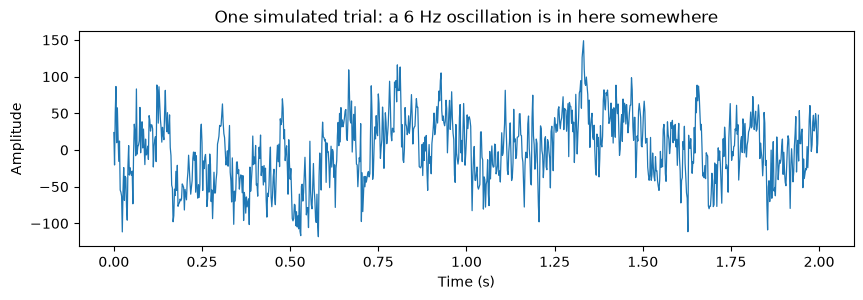

In [6]:
data, times = simulate_trials(n_trials=100, freq=6.0, seed=1)
print("data shape (trials, samples):", data.shape)

plt.figure(figsize=(10, 2.8))
plt.plot(times, data[0], lw=0.9)
plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
plt.title("One simulated trial: a 6 Hz oscillation is in here somewhere")
plt.show()

You cannot see the 6 Hz oscillation by eye; but we know for a fact it is there,
because we put it there. Now let us see whether the Module 10 analysis can find it.

## Measuring power

Let us use the same Morlet wavelet you used in Module 11, and the same pipeline: convolve the signal with the
wavelet -> take the squared magnitude -> average over time. We trim the edges of each trial, because
convolution is unreliable at the ends of the data.

In [19]:
def morlet_wavelet(freq, sample_rate, morlet_reps=5, n_sigma=4):
    '''Complex Morlet wavelet at `freq`, `morlet_reps` cycles wide.'''
    sigma = morlet_reps / (2 * np.pi * freq)
    half = int(np.ceil(n_sigma * sigma * sample_rate))
    t = np.arange(-half, half + 1) / sample_rate
    envelope = np.exp(-t ** 2 / (2 * sigma ** 2)) / np.sqrt(sigma * np.sqrt(np.pi))
    return envelope * np.exp(2j * np.pi * freq * t)


def spectral_power(data, freqs, sample_rate, morlet_reps=5, trim=0.25):
    '''Average power at each frequency, per trial. Returns (n_trials, n_freqs).'''
    data = np.atleast_2d(data)
    edge = int(trim * data.shape[-1])
    power = np.zeros((data.shape[0], len(freqs)))
    for i, freq in enumerate(freqs):
        wavelet = morlet_wavelet(freq, sample_rate, morlet_reps)
        convolved = fftconvolve(data, wavelet[None, :], mode="same", axes=-1)
        power[:, i] = (np.abs(convolved[:, edge:-edge]) ** 2).mean(axis=-1)
    return power

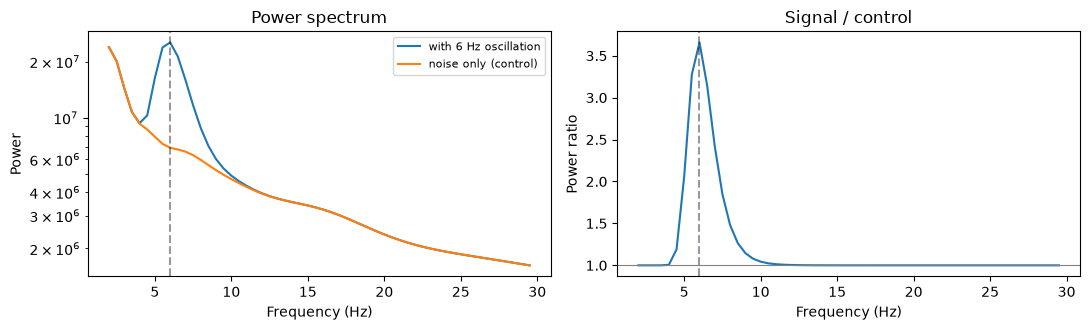

peak of the ratio: 6.0 Hz  (we simulated 6.0 Hz)


In [21]:
analysis_freqs = np.arange(2, 30, 0.5)

with_osc, _ = simulate_trials(100, freq=6.0, oscillation_amplitude=25, seed=1)
without_osc, _ = simulate_trials(100, freq=6.0, oscillation_amplitude=0, seed=1)   # control

power_with = spectral_power(with_osc, analysis_freqs, sample_rate=500).mean(axis=0)
power_without = spectral_power(without_osc, analysis_freqs, sample_rate=500).mean(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogy(analysis_freqs, power_with, label="with 6 Hz oscillation")
ax[0].semilogy(analysis_freqs, power_without, label="noise only (control)")
ax[0].axvline(6, color="k", ls="--", alpha=0.4)
ax[0].set(xlabel="Frequency (Hz)", ylabel="Power", title="Power spectrum")
ax[0].legend(fontsize=8)

ax[1].plot(analysis_freqs, power_with / power_without)
ax[1].axvline(6, color="k", ls="--", alpha=0.4)
ax[1].axhline(1, color="grey", lw=0.8)
ax[1].set(xlabel="Frequency (Hz)", ylabel="Power ratio", title="Signal / control")
plt.tight_layout(); plt.show()

print(f"peak of the ratio: {analysis_freqs[np.argmax(power_with / power_without)]} Hz  (we simulated 6.0 Hz)")

The left panel shows why the control matters: the 1/f background is so steep that at higher
frequencies an oscillation can be real and still not be the biggest thing in the spectrum. Comparing
against a matched control isolates it, which is the logic of the subsequent-memory
analysis in the next module, where the "control" is the other condition.

## Creating a unit test

Everything above was inference by observation. A unit test is computed to verify a result precisely, every time you change the code.

A test is a function that:
- runs your code on input you control,
- and asserts something that must be true.

```python
assert condition, "message shown when this fails"
```

Note:

**Never compare floats with `==`.** `0.1 + 0.2 == 0.3` is `False` in Python. Use `np.isclose` or
`np.allclose` with a tolerance.

**The expected value must come from somewhere independent.** This test looks fine and is worthless:

```python
def test_power_is_correct():
    expected = spectral_power(data, [6.0], 500)     # computed by the code under test!
    assert np.allclose(spectral_power(data, [6.0], 500), expected)   # always passes
```

If the expected answer is produced by the thing you are testing, the test passes no matter how
broken that thing is. Legitimate sources of an expected answer: 1. Theory or a hand-calculation (power should scale as
amplitude squared), 2. Constructed input (we put in 6 Hz, so we should get out 6 Hz), or 3. A trusted library (`scipy`).

In [9]:
def test_pink_noise_is_reproducible():
    a = pink_noise(500, 1.0, np.random.default_rng(3))
    b = pink_noise(500, 1.0, np.random.default_rng(3))
    assert np.array_equal(a, b), "same seed must give identical noise"
    assert not np.array_equal(a, pink_noise(500, 1.0, np.random.default_rng(4))), \
        "different seeds must give different noise"


def test_pink_noise_amplitude_sets_std():
    rng = np.random.default_rng(11)
    draws = [pink_noise(1000, 50.0, rng).std() for _ in range(200)]   # average, not one draw
    assert np.isclose(np.mean(draws), 50.0, rtol=0.05), f"mean std was {np.mean(draws):.2f}"


def test_simulate_trials_shape_and_no_nans():
    data, times = simulate_trials(7, sample_rate=500, duration_s=2.0)
    assert data.shape == (7, 1000), f"unexpected shape {data.shape}"
    assert len(times) == data.shape[1]
    assert not np.isnan(data).any()

Running tests one at a time does not scale. Here is a ten-line runner that finds every `test_*`
function, runs them all, and reports every failure rather than stopping at the first.

(In a real project you would use pytest, which does this and much more, see the end of this module. We use
a local runner so this notebook needs no extra packages.)

In [10]:
def run_tests(namespace=None):
    '''Run every function named test_* and report pass/fail.'''
    namespace = globals() if namespace is None else namespace
    tests = {name: fn for name, fn in namespace.items()
             if name.startswith("test_") and callable(fn)}
    failures = []
    for name, fn in tests.items():
        try:
            fn()
            print(".", end="")
        except Exception as err:
            failures.append((name, err))
            print("F", end="")
    print(f"\n\n{len(tests) - len(failures)} passed, {len(failures)} failed")
    for name, err in failures:
        print(f"  FAILED {name}: {err}")


run_tests()

...

3 passed, 0 failed


### Always make a test fail on purpose

A test that has never failed is not evidence of anything, as you have no idea whether it CAN
fail. Here we break the wavelet deliberately just to confirm if the test notices.

In [ ]:
def morlet_wavelet_buggy(freq, sample_rate, morlet_reps=5, n_sigma=4):
    sigma = morlet_reps / (2 * np.pi * freq)
    half = int(np.ceil(n_sigma * sigma * sample_rate))
    t = np.arange(-half, half + 1) / sample_rate
    envelope = np.exp(-t ** 2 / (2 * sigma ** 2)) / np.sqrt(sigma * np.sqrt(np.pi))
    return envelope * np.exp(2j * np.pi * freq * t / 2)          # <- bug: frequency halved


# Named without the test_ prefix so the runner does not pick it up later: it is meant to fail.
def check_buggy_wavelet():
    wavelet = morlet_wavelet_buggy(6.0, sample_rate=500)
    kfreqs = np.fft.rfftfreq(8192, 1 / 500)
    peak = kfreqs[np.argmax(np.abs(np.fft.rfft(wavelet.real, 8192)))]
    assert np.isclose(peak, 6.0, rtol=0.02), f"6 Hz wavelet actually peaked at {peak:.2f} Hz"


run_tests({"test_wavelet_frequency": check_buggy_wavelet})

F

0 passed, 1 failed
  FAILED test_wavelet_frequency: 6 Hz wavelet actually peaked at 2.99 Hz


Note: Write your assertion messages such that the failure message reports the incorrect numbers, not just "something was wrong".

## Result recovery test

Now we move on to the tests that actually check the science. Both get their expected answer from outside the
code being tested:

- **We put in 6 Hz, so the peak must be at 6 Hz.** The expected answer is our own input.
- **Power is amplitude squared.** That is always true - Doubling the amplitude must quadruple the power, and this holds no matter how the wavelet is normalized, which makes it a strong check.

In [12]:
def test_power_peaks_at_the_simulated_frequency():
    freqs = np.arange(2, 40, 0.5)
    for simulated in [4.0, 6.0, 10.0, 20.0]:
        signal, _ = simulate_trials(60, freq=simulated, oscillation_amplitude=25, seed=1)
        control, _ = simulate_trials(60, freq=simulated, oscillation_amplitude=0, seed=1)
        ratio = (spectral_power(signal, freqs, 500).mean(0)
                 / spectral_power(control, freqs, 500).mean(0))
        peak = freqs[np.argmax(ratio)]
        assert np.isclose(peak, simulated, atol=0.5), \
            f"simulated {simulated} Hz but power peaked at {peak} Hz"


def test_power_scales_with_amplitude_squared():
    powers = {}
    for amplitude in [10.0, 20.0, 40.0]:
        data, _ = simulate_trials(20, freq=6.0, oscillation_amplitude=amplitude,
                                  noise_amplitude=0.0, seed=2)
        powers[amplitude] = spectral_power(data, [6.0], 500).mean()
    assert np.isclose(powers[20.0] / powers[10.0], 4.0, rtol=0.01), "doubling should quadruple"
    assert np.isclose(powers[40.0] / powers[10.0], 16.0, rtol=0.01), "4x should be 16x"


def test_no_oscillation_means_no_peak():
    freqs = np.arange(2, 40, 0.5)
    data, _ = simulate_trials(60, oscillation_amplitude=0.0, seed=3)
    power = spectral_power(data, freqs, 500).mean(0)
    assert np.argmax(power) == 0, "pure 1/f noise should have its maximum at the lowest frequency"


run_tests()

......

6 passed, 0 failed


## Simulated subsequent-memory effect

Now we can simulate the actual experiment in the next module. Half the trials are "recalled" and get a stronger
6 Hz oscillation; the rest are "not recalled" and get a weaker one. We know the effect is real,
because we built it.

In [13]:
def simulate_experiment(n_trials=200, freq=6.0, recalled_amplitude=25.0,
                        not_recalled_amplitude=15.0, noise_amplitude=50.0,
                        sample_rate=500, duration_s=2.0, seed=0):
    '''An experiment with a known subsequent-memory effect. Returns (data, recalled, times).'''
    rng = np.random.default_rng(seed)
    recalled = rng.random(n_trials) < 0.5
    n_samples = int(duration_s * sample_rate)
    times = np.arange(n_samples) / sample_rate
    data = np.zeros((n_trials, n_samples))
    for trial in range(n_trials):
        amplitude = recalled_amplitude if recalled[trial] else not_recalled_amplitude
        start_phase = rng.uniform(0, 2 * np.pi)
        data[trial] = amplitude * np.sin(2 * np.pi * freq * times + start_phase)
        data[trial] += pink_noise(n_samples, noise_amplitude, rng)
    return data, recalled, times

recalled  : mean log power 7.358  (n = 103)
not recalled: mean log power 7.134  (n = 97)
t = 7.61, p = 1.09e-12


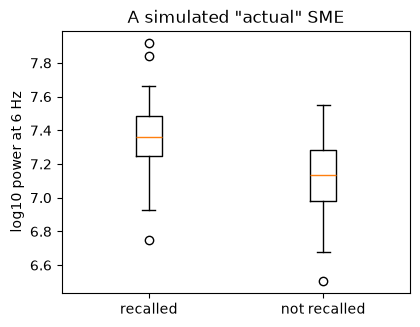

In [23]:
data, recalled, _ = simulate_experiment(n_trials=200, seed=5)
log_power = np.log10(spectral_power(data, [6.0], sample_rate=500)[:, 0])

t_stat, p_value = ttest_ind(log_power[recalled], log_power[~recalled])
print(f"recalled  : mean log power {log_power[recalled].mean():.3f}  (n = {recalled.sum()})")
print(f"not recalled: mean log power {log_power[~recalled].mean():.3f}  (n = {(~recalled).sum()})")
print(f"t = {t_stat:.2f}, p = {p_value:.2e}")

plt.figure(figsize=(4.5, 3.4))
plt.boxplot([log_power[recalled], log_power[~recalled]])
plt.xticks([1, 2], ["recalled", "not recalled"])
plt.ylabel("log10 power at 6 Hz")
plt.title("A simulated \"actual\" SME")
plt.show()

In [15]:
def test_recovers_a_known_memory_effect():
    data, recalled, _ = simulate_experiment(200, recalled_amplitude=25.0,
                                            not_recalled_amplitude=15.0, seed=5)
    power = np.log10(spectral_power(data, [6.0], 500)[:, 0])
    t_stat, p_value = ttest_ind(power[recalled], power[~recalled])   # scipy, not our own stats
    assert t_stat > 0, "recalled trials had MORE power, so t must be positive"
    assert p_value < 0.001, f"a large planted effect should be detected, got p = {p_value:.3g}"


run_tests()

.......

7 passed, 0 failed


## Final test: no effect

Here we finally ask: when there is NO memory effect at all, how
often does your pipeline say there is one?

Set both amplitudes equal, so recalled and non-recalled trials are drawn from exactly the same
distribution, and run the whole experiment 400 times.

400 experiments with NO real effect
fraction with p < 0.05: 0.058   (should be about 0.05)


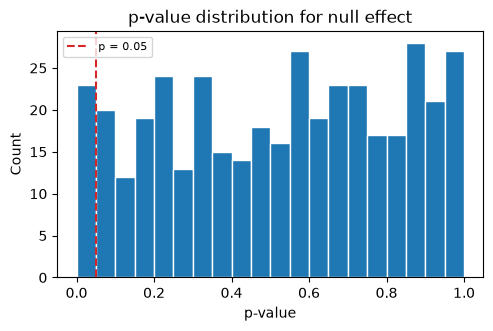

In [27]:
null_p_values = []
for seed in range(400):
    data, recalled, _ = simulate_experiment(100, recalled_amplitude=20.0,
                                            not_recalled_amplitude=20.0, seed=3000 + seed)
    power = np.log10(spectral_power(data, [6.0], 500)[:, 0])
    null_p_values.append(ttest_ind(power[recalled], power[~recalled])[1])
null_p_values = np.array(null_p_values)

print(f"{len(null_p_values)} experiments with NO real effect")
print(f"fraction with p < 0.05: {(null_p_values < 0.05).mean():.3f}   (should be about 0.05)")

plt.figure(figsize=(5.5, 3.2))
plt.hist(null_p_values, bins=20, range=(0, 1), edgecolor="white")
plt.axvline(0.05, color="C3", ls="--", label="p = 0.05")
plt.xlabel("p-value"); plt.ylabel("Count")
plt.title("p-value distribution for null effect")
plt.legend(fontsize=8); plt.show()

Observations:

**The result is flat.** This is what a correct pipeline looks like under the null — every p-value is equally
likely. A pipeline with a subtle bug (leaking condition information, reusing a trial, averaging the
wrong axis) produces a histogram that leans left, and you would never notice on real data.

**About 5% of experiments are "significant" anyway.** That is not a flaw, it is the definition of
$p < 0.05$. But now watch what happens when you test more than one frequency.

In [25]:
def test_null_experiment_has_the_right_false_positive_rate():
    p_values = []
    for seed in range(200):
        data, recalled, _ = simulate_experiment(100, recalled_amplitude=20.0,
                                                not_recalled_amplitude=20.0, seed=3000 + seed)
        power = np.log10(spectral_power(data, [6.0], 500)[:, 0])
        p_values.append(ttest_ind(power[recalled], power[~recalled])[1])
    rate = np.mean(np.array(p_values) < 0.05)
    assert 0.01 < rate < 0.12, f"false positive rate {rate:.3f} is not close to 0.05"


run_tests()

........

8 passed, 0 failed


### Importance of multiple comparisons

A real spectral analysis does not test one frequency, it tests a whole spectrum at every electrode.
Let us run the same null experiment, but ask "is there
a significant effect at ANY of my 20 frequencies?"

In [26]:
freq_grid = np.logspace(np.log10(2), np.log10(60), 20)
any_significant = []
for seed in range(150):
    data, recalled, _ = simulate_experiment(100, recalled_amplitude=20.0,
                                            not_recalled_amplitude=20.0, seed=9000 + seed)
    power = np.log10(spectral_power(data, freq_grid, 500))
    _, p_values = ttest_ind(power[recalled], power[~recalled], axis=0)
    any_significant.append((p_values < 0.05).any())

print(f"Testing 1 frequency  -> false positive about  5% of the time")
print(f"Testing 20 frequencies -> at least one 'significant' result in "
      f"{100 * np.mean(any_significant):.0f}% of experiments with NO real effect")

Testing 1 frequency  -> false positive about  5% of the time
Testing 20 frequencies -> at least one 'significant' result in 54% of experiments with NO real effect


Roughly half of all experiments with nothing whatsoever going on yield at least one significant
frequency. And a real analysis has more than 20 frequencies and more than one electrode.

This is the multiple-comparisons problem from Module 9, which you will fix in the next module — with Bonferroni
correction, FDR, or permutation tests. When you get there, come back and run those corrections
against this null simulation to confirm they actually bring the number back down to 5%.

## Outside the notebook: pytest

Real projects keep functions in a `.py` file and tests in a `test_*.py` file beside it, run from the
terminal:

```bash
pip install pytest      # or: conda install pytest
pytest -q test_analysis.py
```

Pytest finds every `test_*` function automatically — the tests you wrote above would work unchanged,
which is the whole reason for the naming convention. It also gives you:

```python
import pytest

assert power == pytest.approx(4.0, rel=0.01)   # float comparison, done properly

with pytest.raises(ValueError):                # assert that bad input is rejected
    spectral_power(data, freqs=[], sample_rate=500)

@pytest.mark.parametrize("freq", [4.0, 6.0, 10.0])   # one test body, many inputs
def test_power_peaks_at_the_simulated_frequency(freq):
    ...
```

Reach for this the moment a function is used by more than one notebook.


**Exercise - how many trials do you need?**
Run `simulate_experiment` with `recalled_amplitude=22`, `not_recalled_amplitude=18` (a much smaller
effect) at `n_trials` of 50, 100, 400, and 1600. For each, repeat 100 times and record how often
$p < 0.05$. That fraction is your **statistical power**. How many trials do you need to detect this
effect 80% of the time?